# Defining custom markets and an associated fleet

AeroMAPS ships with a default 4-market structure (`short_range`, `medium_range`, `long_range`, `freight`), but you can replace it with **user-defined markets** declared in YAML. The market concept is the top-level grouping for traffic, energy intensity, and fleet renewal — downstream models (energy, emissions, costs) auto-adapt to whatever markets you declare.

This tutorial walks through a minimal example with **three markets**: two passenger markets (replacing the default short/medium/long split) and one freight market.

| Market id | Name | Type | RPK / RTK share 2019 | Energy share 2019 |
|-----------|------|------|:--------------------:|:-----------------:|
| `regional` | Regional | passenger | 62.3 % | 52.19 % |
| `intercontinental` | Intercontinental | passenger | 37.7 % | 32.81 % |
| `air_cargo` | Air Cargo | freight | 100 % | 15 % |

We will:
1. Write the three YAML files that describe the scenario.
2. Point a `config.yaml` at them.
3. Build the process, run it, and inspect per-market results.

## 1. The four input files

A custom scenario is fully described by **four YAML files**, all kept side-by-side under `data/`:

| File | Role |
|------|------|
| `custom_markets.yaml` | declares each market — id, traffic type, last-historical-year calibration, growth, COVID, efficiency... |
| `custom_fleet.yaml` | declares the fleet structure for each *passenger* market (subcategories, shares) |
| `custom_aircraft_inventory.yaml` | declares the reference + new aircraft used by the fleet |
| `config.yaml` | wires the three together and selects which AeroMAPS models to run |

Let's look at each in turn.

### 1.a — `custom_markets.yaml`

Each top-level key (other than `global` and `defaults`) declares one market. The required keys are `name`, `traffic_type` (`passenger`|`freight`), `traffic_unit` (`RPK`|`RTK`), and `inputs.initial` (calibration at the last historical year — 2019 in this tutorial). All other input blocks (`growth`, `covid`, `load_factor`, `measures`, `efficiency_simple`, `costs`, `reference`) are *optional* — anything you omit falls back to the values declared under `defaults`.

The optional `global:` block holds settings shared across all markets:
* `demand.model` — build-time selector of the passenger demand model (`cagr` default, `cagr_elasticity`, `constant_elasticity`, `logistic_income`);
* `load_factor.model` — load factor model selector (`quadratic` default, `simple_interpolation`);
* other sub-blocks (e.g. `elasticity`) — scalar parameters pushed into the AeroMAPS variable space without market prefix.

**Conservation constraints** (a hard error is raised at process creation if violated):
* `rpk_share_last_historical_year` across all passenger markets must sum to 100.
* `energy_share_last_historical_year` across **all** markets (passenger + freight) must sum to 100.
* For freight markets, the per-market `rtk_share_last_historical_year` must sum to 100 across freight markets (here we have a single freight market, so it is 100).

In [1]:
from pathlib import Path

print(Path("data/custom_markets.yaml").read_text())

# Custom market definitions for Phase 3 smoke test.
# Uses 2 passenger markets instead of the default 3, plus 1 freight market.
#
#   regional        — combines short + medium haul (62.3 % of RPK)
#   intercontinental — long-haul only              (37.7 % of RPK)
#   air_cargo       — all-freighter ops            (15 %  of energy)
#
# rpk_share_last_historical_year  must sum to 100 across passenger markets : 62.3 + 37.7 = 100 ✓
# energy_share_last_historical_year must sum to 85  across passenger markets : 52.19 + 32.81 = 85 ✓
# freight energy_share_last_historical_year = 15.0 → grand total = 100 ✓

# Optional settings shared across all markets. This block can be omitted
# entirely — the values below are the defaults. See the
# 08_use_variable_demand tutorial for the price-elastic demand modes
# (cagr_elasticity, constant_elasticity, logistic_income) and their
# ``elasticity`` calibration block.
global:
  # Passenger demand model selector (build-time, not a model parameter):
  # cagr | 

### 1.b — `custom_fleet.yaml`

Declares the fleet structure for each **passenger** market (freight markets are handled through the freight efficiency model and need no fleet entry). Two top-level blocks:

* `subcategories:` — the subcategory pool. Each subcategory has a `share` within its market (subcategory shares **must sum to 100 % per market**), optional `reference_aircraft` (old + recent baseline) and a list of `aircraft:` entries.
* `categories:` — one entry per passenger market, with `market_served:` matching a market id from `custom_markets.yaml`, the renewal `parameters` (`life`, `limit`), and the ordered list of `subcategories` it draws from.

In [2]:
print(Path("data/custom_fleet.yaml").read_text())

# Fleet structure for the Phase 3 custom-market smoke test.
#
# Two passenger markets (regional, intercontinental) matching custom_markets.yaml.
# market_served must match a market id declared in custom_markets.yaml.
#
#   regional        → 2 subcategories: conventional NB (75 %) + hydrogen NB (25 %)
#   intercontinental → 1 subcategory: conventional WB (100 %)
#
# Subcategory shares within each category must sum to 100 %.

subcategories:
  - id: regional_conventional_nb
    name: "Regional conventional NB"
    share: 75.0
    reference_aircraft:
      old_ref: regional_conventional_nb_old
      recent_ref: regional_conventional_nb_recent
    aircraft:
      - regional_nb_2035

  - id: regional_hydrogen_nb
    name: "Regional hydrogen NB"
    share: 25.0
    aircraft:
      - regional_h2_2040

  - id: intercont_conventional_wb
    name: "Intercontinental conventional WB"
    share: 100.0
    reference_aircraft:
      old_ref: intercont_conventional_wb_old
      recent_ref: intercont_co

### 1.c — `custom_aircraft_inventory.yaml`

Two blocks:

* `reference_aircraft:` — the *old* and *recent* baseline aircraft each subcategory calibrates against (absolute values: energy per ASK, NOx and soot emission indices, base DOC, ASK/year per airframe, OEW, recurring/non-recurring costs).
* `aircraft:` — the new aircraft entering service. Each one references a `reference_aircraft` and a `entry_into_service_year`, and is described as **relative deltas** vs that reference (`consumption_evolution`, `nox_evolution`, `soot_evolution`, `doc_non_energy_evolution`, `hybridization_factor`).

In [3]:
print(Path("data/custom_aircraft_inventory.yaml").read_text())

# Aircraft inventory for the Phase 3 custom-market smoke test.
# Two passenger markets (regional, intercontinental) + one freight market.
#
# Energy values are derived from the default fleet defaults:
#   regional        → weighted blend of default SR and MR reference aircraft
#   intercontinental → identical to default LR reference aircraft

reference_aircraft:
  # ── Regional reference aircraft ──────────────────────────────────────────
  - id: regional_conventional_nb_old
    name: "Regional conventional NB — legacy"
    parameters:
      entry_into_service_year: 1970.0
      energy_per_ask: 1.1       # blend of SR (1.247) and MR (0.916)
      emission_index_nox: 0.01514
      emission_index_soot: 0.00003
      doc_non_energy_base: 0.038
      cruise_altitude: 12000.0
      ask_year: 320000000.0     # between SR 280M and MR 352M
      rc_cost: 50000000.0
      nrc_cost: 10000000000.0
      oew: 40.0

  - id: regional_conventional_nb_recent
    name: "Regional conventional NB — recen

### 1.d — `config.yaml`

Glues the three input files together and selects the AeroMAPS model standards to run. The relevant blocks are `models.markets`, `models.fleet`, and `models.standards`.

In [4]:
print(Path("data/config.yaml").read_text())

data:
  outputs:
    json_outputs_file: "./outputs.json"


models:
  fleet:
    fleet_model_data_file: "./custom_fleet.yaml"
    aircraft_inventory_model_data_file: "./custom_aircraft_inventory.yaml"

  markets:
    markets_data_file: "./custom_markets.yaml"

  energy:
    energy_carriers_model_data_file: default
    resources_model_data_file: default
    processes_model_data_file: default

  standards:
    - models_traffic
    - models_efficiency_bottom_up
    - models_energy_without_fuel_effect
    - models_energy_cost
    - models_offset
    - models_emissions



## 2. Build and run the process

Passing the config file to `create_process` is enough — the markets, fleet, and aircraft inventory are all picked up from the YAML references.

In [5]:
from aeromaps import create_process

process = create_process(configuration_file="data/config.yaml")
process.compute()

## 3. Inspect the loaded markets and fleet

The `MarketManager` exposes every market declared in the YAML.

In [6]:
for m in process.markets:
    print(f"{m.id:20s}  name={m.name!r:22s}  type={m.traffic_type:10s}  unit={m.traffic_unit}")

regional              name='Regional'              type=passenger   unit=RPK
intercontinental      name='Intercontinental'      type=passenger   unit=RPK
air_cargo             name='Air Cargo'             type=freight     unit=RTK


In [7]:
for cat_name, cat in process.fleet_model.fleet.categories.items():
    subcats = [sc.name for sc in cat.subcategories.values()]
    print(f"[{cat.market_id:18s}] {cat_name!r:25s}  subcategories={subcats}")

[regional          ] 'Regional'                 subcategories=['Regional conventional NB', 'Regional hydrogen NB']
[intercontinental  ] 'Intercontinental'         subcategories=['Intercontinental conventional WB']


## 4. Per-market results

Downstream outputs are now templated with the market id. The traffic series follow the convention `rpk_<market>` for passenger markets and `rtk_<market>` for freight markets; CO2 follows `co2_emissions_<market>`.

In [8]:
vector = process.data["vector_outputs"]
years = [2019, 2030, 2050]

traffic_cols = ["rpk_regional", "rpk_intercontinental", "rtk_air_cargo"]
(vector[traffic_cols] / 1e9).loc[years].round(2)

,rpk_regional,rpk_intercontinental,rtk_air_cargo
2019,5411.17,3274.50,225.00
2030,6461.22,3909.92,268.66
2050,11669.69,7061.75,485.24


In [9]:
vector[["rpk", "ask", "load_factor", "co2_emissions_passenger", "co2_emissions_freight"]].loc[years]

,rpk,ask,load_factor,co2_emissions_passenger,co2_emissions_freight
2019,8.685670e+12,1.054090e+13,82.399700,958.353384,169.121185
2030,1.037114e+13,1.235883e+13,83.916872,902.532012,162.171421
2050,1.873144e+13,2.203699e+13,85.000000,589.579568,107.286418


### Per-market CO₂ emissions

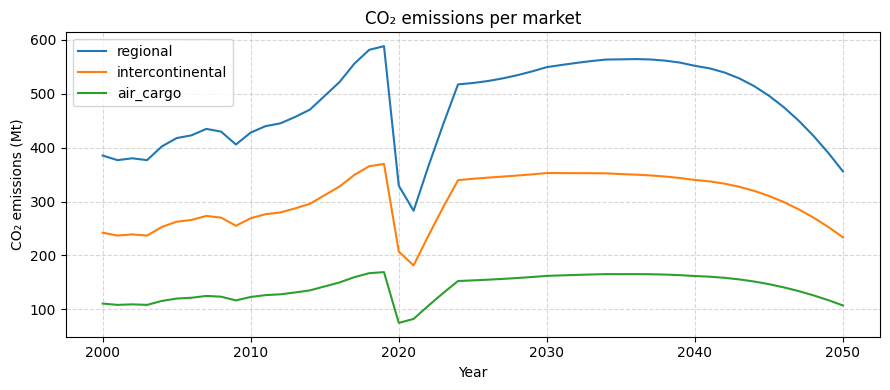

In [10]:
import matplotlib.pyplot as plt

market_ids = [m.id for m in process.markets]
co2_cols = [f"co2_emissions_{mid}" for mid in market_ids]

fig, ax = plt.subplots(figsize=(9, 4))
for col, mid in zip(co2_cols, market_ids):
    if col in vector.columns:
        ax.plot(vector.index, vector[col], label=mid)

ax.set_xlabel("Year")
ax.set_ylabel("CO₂ emissions (Mt)")
ax.set_title("CO₂ emissions per market")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Decompose the CO₂ levers of action

The CO₂ wedges follow the custom markets and fleet without further input: the decomposition models are registered with the bottom-up efficiency and generic energy standards used here. Every split is exact, the sub-wedges summing to the wedge they replace.

The starting point is the usual cascade of levers of action.

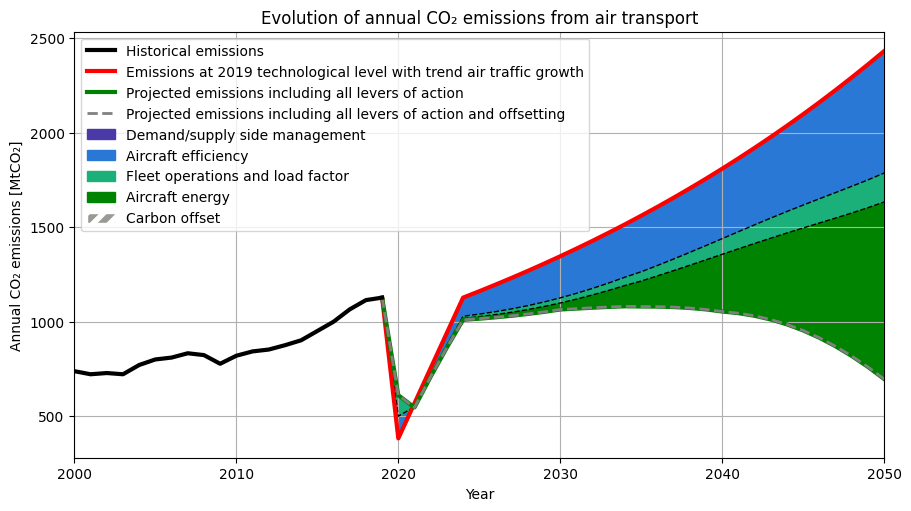

In [11]:
process.plot("air_transport_co2_emissions", save=False)

### Efficiency per aircraft, energy per pathway

`air_transport_co2_emissions_detailed` splits the aircraft-efficiency wedge into fleet renewal and one band per new aircraft of `custom_aircraft_inventory.yaml`, and the aircraft-energy wedge into one band per energy pathway. This configuration does not declare `models.operations`, so the operations wedge stays a single band; tutorial 15 shows its split per operational concept.

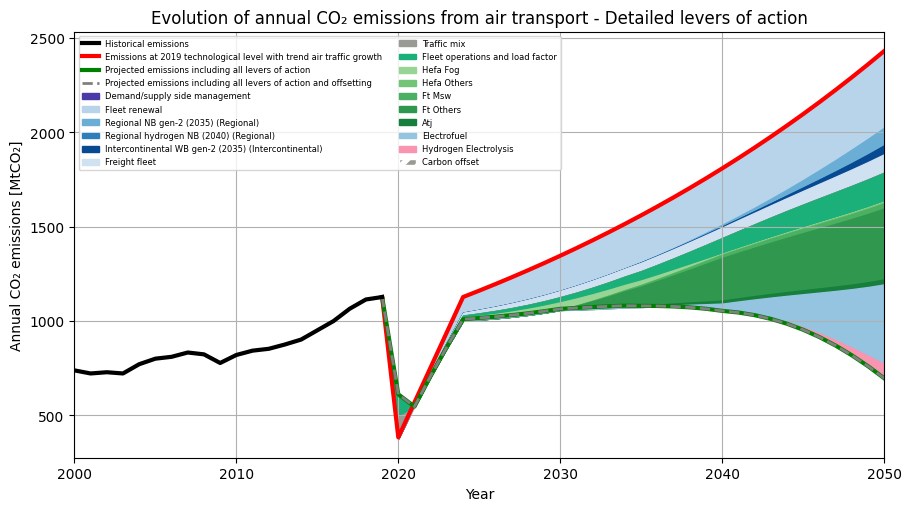

In [12]:
process.plot("air_transport_co2_emissions_detailed", save=False)

### Coarser granularity

`efficiency_granularity="category"` sums the aircraft within each fleet category of `custom_fleet.yaml`, and `energy_granularity="family"` groups the pathways into biofuels, electrofuels, fossil-derived, hydrogen and electric. `air_transport_co2_emissions_grouped` applies both.

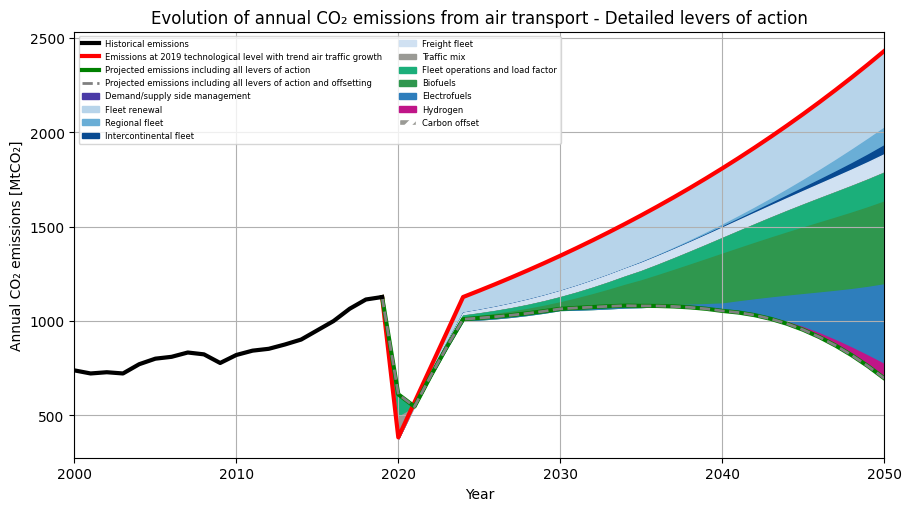

In [13]:
process.plot("air_transport_co2_emissions_grouped", save=False)

The two keywords are independent, for instance categories for efficiency and pathways for energy.

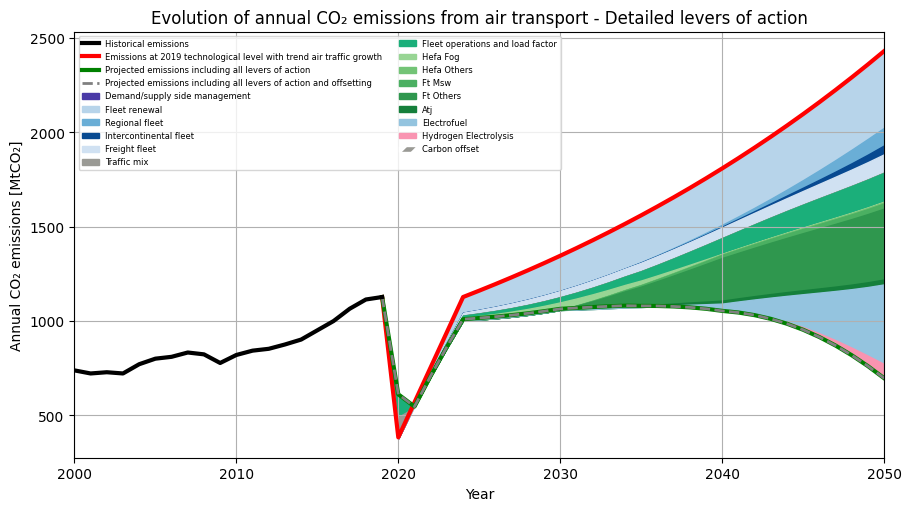

In [14]:
process.plot(
    "air_transport_co2_emissions_detailed",
    save=False,
    efficiency_granularity="category",
    energy_granularity="pathway",
)

### Every wedge per market

`air_transport_co2_emissions_per_market` recomputes the cascade for each market with its own traffic and energy intensity, one panel per lever. The markets do not add up exactly to the global lever, since the global cascade uses fleet-wide intensities: the cross-market-mix line is that residual, the effect of traffic shifting between markets of different intensity.

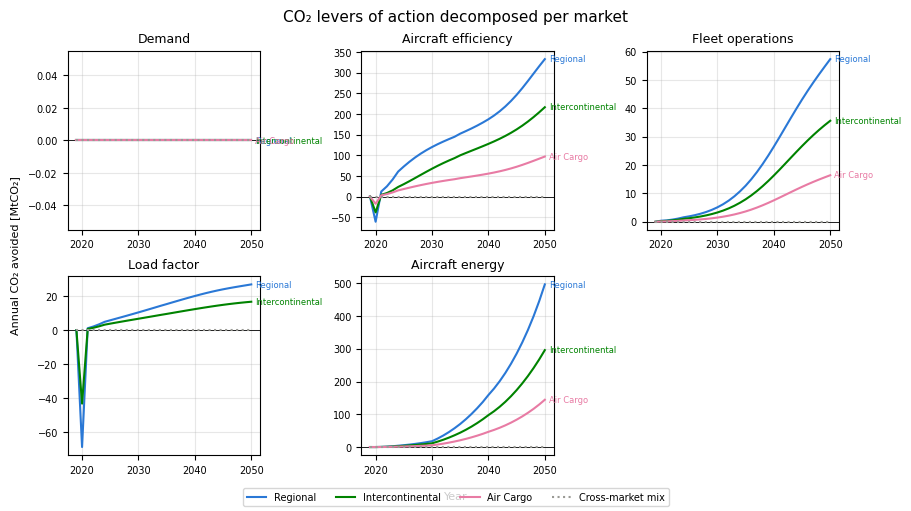

In [15]:
process.plot("air_transport_co2_emissions_per_market", save=False)

The same values are available as a table with a `(lever, market)` column index.

In [16]:
from aeromaps.models.impacts.emissions.co2_emissions import market_lever_dataframe

per_market = market_lever_dataframe(vector, process.markets)
per_market.loc[[2030, 2040, 2050]].round(1)

lever,demand,efficiency,operations,loadfactor,energy,demand,efficiency,operations,loadfactor,energy,demand,efficiency,operations,energy,demand,efficiency,operations,loadfactor,energy
market,regional,regional,regional,regional,regional,intercontinental,intercontinental,intercontinental,intercontinental,intercontinental,air_cargo,air_cargo,air_cargo,air_cargo,cross_mix,cross_mix,cross_mix,cross_mix,cross_mix
2030,0.0,119.7,5.1,10.4,17.8,0.0,67.3,3.3,6.7,11.4,0.0,33.0,1.5,5.3,0.0,0.0,0.0,0.0,0.0
2040,0.0,186.9,26.5,20.1,158.8,0.0,127.4,16.3,12.4,97.4,0.0,55.4,7.6,46.5,0.0,0.0,0.0,0.0,0.0
2050,0.0,332.4,57.4,26.9,496.4,0.0,216.0,35.6,16.7,295.8,0.0,96.7,16.4,144.3,0.0,0.0,0.0,0.0,0.0


## 6. What to change to define your own scenario

To adapt this template to your case:

1. **Edit `custom_markets.yaml`** — add/remove market blocks, change `rpk_share_last_historical_year` / `rtk_share_last_historical_year` / `energy_share_last_historical_year` (keep the conservation constraints), and override any `defaults` block per market when needed (e.g. different growth curve, COVID profile, or hydrogen introduction year per market).
2. **Edit `custom_fleet.yaml`** — make sure every passenger market in `custom_markets.yaml` has a matching `market_served:` entry. Define the subcategories and their `share` (must sum to 100 % per market).
3. **Edit `custom_aircraft_inventory.yaml`** — add the reference and new aircraft referenced from the fleet.
4. **Leave `config.yaml` as-is** if you keep the same file names, otherwise update the three `*_data_file:` paths.

No Python code changes are needed: market names propagate through traffic, ASK, fleet, energy consumption, emissions, and cost models automatically.